<a href="https://colab.research.google.com/github/amritasingh13032004-source/web-development/blob/main/RED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

base_path = "/content/drive/MyDrive"
os.listdir(base_path)


['Iris project',
 'Colab Notebooks',
 'Photos',
 'Video',
 'REDUCTION_USE',
 'Downloads']

In [ ]:
dataset_path = "/content/drive/MyDrive/REDUCTION_USE"
import os
os.listdir(dataset_path)


['A00000T16N00x15.wav',
 'A00000T16N00x08.wav',
 'A00000T16N00x10.wav',
 'A00000T16N00x11.wav',
 'A00000T16N00x16.wav',
 'A00000T16N00x01.wav',
 'A00000T16N00x14.wav',
 'A00000T16N00x09.wav',
 'A00000T16N00x13.wav',
 'A00000T16N00x04.wav',
 'A00000T16N00x07.wav',
 'A00000T16N00x05.wav',
 'A00000T16N00x02.wav',
 'A00000T16N00x12.wav',
 'A00000T16N00x06.wav',
 'A00000T16N00x03.wav',
 'REDUCTION_USE']

In [ ]:
dataset_path = "/content/drive/MyDrive/REDUCTION_USE/REDUCTION_USE"


In [ ]:
dataset_path = "/content/drive/MyDrive/REDUCTION_USE/REDUCTION_USE"

In [ ]:
import librosa

audio_files = [f for f in os.listdir(dataset_path) if f.endswith('.wav')]
print("Total audio files:", len(audio_files))

audio_path = os.path.join(dataset_path, audio_files[0])
y, sr = librosa.load(audio_path)

print("Loaded successfully")
print("Sample rate:", sr)
print("Duration (sec):", len(y)/sr)


Total audio files: 168
Loaded successfully
Sample rate: 22050
Duration (sec): 60.0


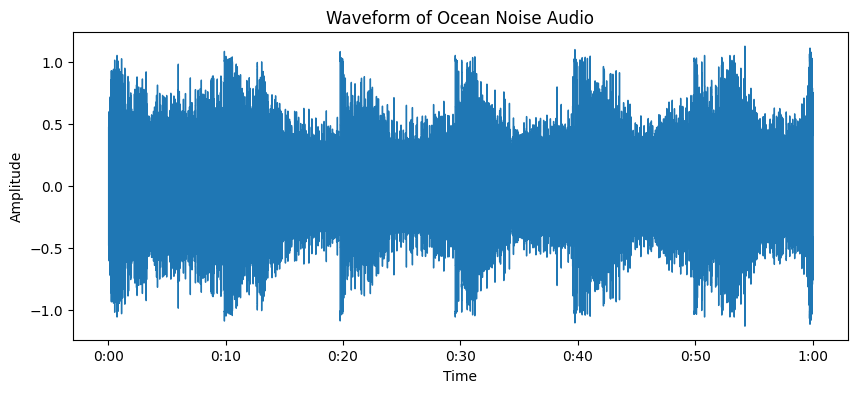

In [ ]:
import matplotlib.pyplot as plt
import librosa.display

plt.figure(figsize=(10, 4))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform of Ocean Noise Audio")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()


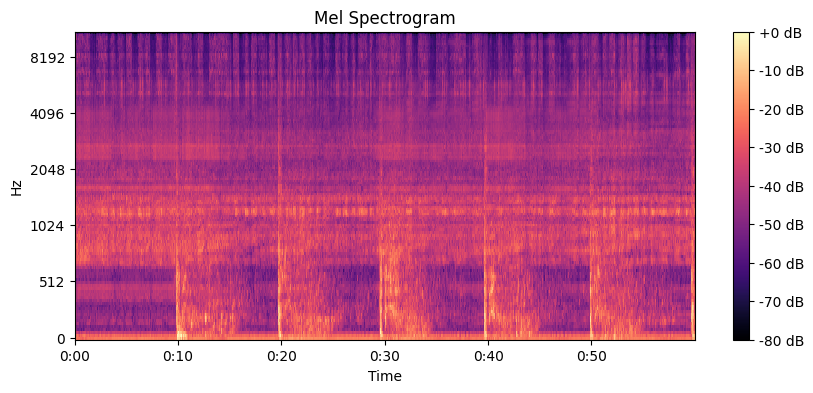

In [ ]:
import numpy as np

S = librosa.feature.melspectrogram(y=y, sr=sr)
S_db = librosa.power_to_db(S, ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title("Mel Spectrogram")
plt.show()


In [ ]:
mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
print("MFCC shape:", mfcc.shape)


MFCC shape: (13, 2584)


In [ ]:
features = []

for file in audio_files:
    path = os.path.join(dataset_path, file)
    y, sr = librosa.load(path)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    features.append(mfcc.mean(axis=1))


In [ ]:
labels = [1, 0, 1, 2, ...]  # based on your dataset


In [ ]:
import os
import librosa
import numpy as np

features = []
labels = []

dataset_path = "path_to_your_dataset"

for file in os.listdir(dataset_path):
    if file.endswith(".wav"):
        file_path = os.path.join(dataset_path, file)

        y, sr = librosa.load(file_path, duration=5)  # fixed duration
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

        mfcc_mean = np.mean(mfcc, axis=1)  # FIXED size (13,)
        features.append(mfcc_mean)

        # example label (change as per your dataset)
        labels.append(1)   # ship noise / ocean noise


FileNotFoundError: [Errno 2] No such file or directory: 'path_to_your_dataset'

In [ ]:
dataset_path = "/content/drive/MyDrive/ocean_audio_dataset"


In [ ]:
import os

print(os.listdir(dataset_path)[:5])  # show first 5 files


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/ocean_audio_dataset'

In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/REDUCTION_USE/REDUCTION_USE")[:5])  # show first 5 files


['A20000T01N00.wav', 'A20000T00N08x04.wav', 'A20000T00N08x05.wav', 'A20000T16N00.wav', 'A20000T02N00.wav']


In [ ]:
import os
import librosa
import numpy as np

dataset_path = "/content/drive/MyDrive/REDUCTION_USE/REDUCTION_USE"

features = []
labels = []

for file in os.listdir(dataset_path):
    if file.endswith(".wav"):
        file_path = os.path.join(dataset_path, file)

        y, sr = librosa.load(file_path, duration=5)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

        mfcc_mean = np.mean(mfcc, axis=1)
        features.append(mfcc_mean)

        labels.append(1)


In [ ]:
print("Total files:", len(os.listdir("/content/drive/MyDrive/REDUCTION_USE/REDUCTION_USE")))
print("Extracted features:", len(features))


Total files: 170
Extracted features: 168


In [ ]:
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib


In [ ]:
dataset_path = "/content/drive/MyDrive/REDUCTION_USE/REDUCTION_USE"


In [ ]:
X = np.array(features)
y = np.array(labels)

print("Feature shape:", X.shape)
print("Label shape:", y.shape)


Feature shape: (168, 13)
Label shape: (168,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)


Training samples: (134, 13)
Testing samples: (34, 13)


In [ ]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)
print("Model trained successfully ✅")


Model trained successfully ✅


In [ ]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 1.0
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        34

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


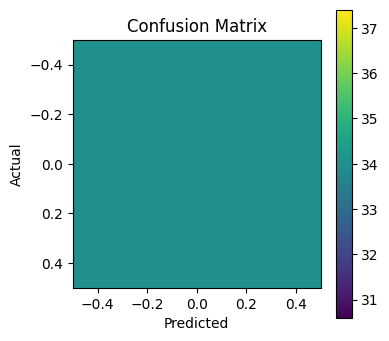

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4, 4))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()


In [ ]:
joblib.dump(model, "ocean_noise_model.pkl")
print("Model saved successfully 💾")


Model saved successfully 💾


In [ ]:
!pip install noisereduce


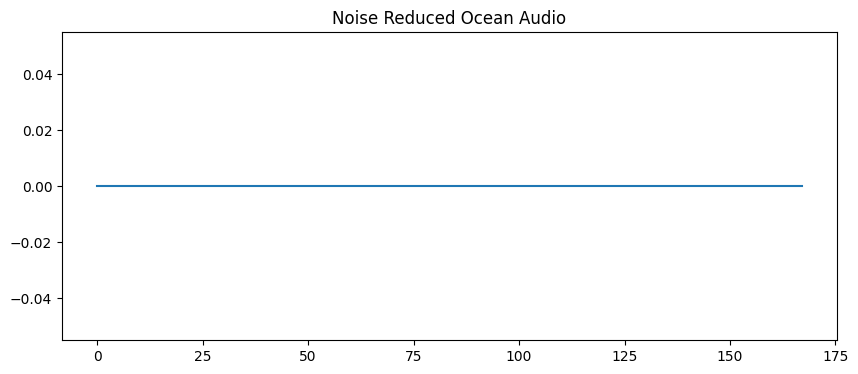

In [ ]:
import noisereduce as nr

reduced_noise = nr.reduce_noise(y=y, sr=sr)

plt.figure(figsize=(10, 4))
plt.plot(reduced_noise)
plt.title("Noise Reduced Ocean Audio")
plt.show()


In [ ]:
import os
import librosa
import numpy as np

test_file = os.listdir("/content/drive/MyDrive/REDUCTION_USE/REDUCTION_USE")[0]   # first audio file
test_path = os.path.join("/content/drive/MyDrive/REDUCTION_USE/REDUCTION_USE", test_file)

print("Testing on file:", test_file)



Testing on file: A20000T01N00.wav


In [ ]:
test_audio, sr = librosa.load(test_path, duration=5)

mfcc = librosa.feature.mfcc(y=test_audio, sr=sr, n_mfcc=13)
mfcc_mean = np.mean(mfcc, axis=1)

prediction = model.predict([mfcc_mean])
print("Predicted class:", prediction)


Predicted class: [1]


In [ ]:
# Test model on unseen audio (from dataset)

import librosa
import numpy as np
import os

test_file = os.listdir(dataset_path)[0]
test_path = os.path.join(dataset_path, test_file)

test_audio, sr = librosa.load(test_path, duration=5)

mfcc = librosa.feature.mfcc(y=test_audio, sr=sr, n_mfcc=13)
mfcc_mean = np.mean(mfcc, axis=1)

prediction = model.predict([mfcc_mean])

print("Test file:", test_file)
print("Predicted class:", prediction)


Test file: A20000T01N00.wav
Predicted class: [1]
